In [1]:
from funciones import insert_into_table_sitios

In [2]:
path_dir = r'C:\Data\metadata-sitios-20250319T175711Z-001'  # Reemplaza con la ruta real a tu directorio
insert_into_table_sitios(path_dir)

Data inserted successfully into the table 'sitios'!


In [3]:
path_dir = r'C:\Data\metadata-sitios-20250319T175711Z-002'  # Reemplaza con la ruta real a tu directorio
insert_into_table_sitios(path_dir)

Data inserted successfully into the table 'sitios'!


In [4]:
from funciones import get_connection_engine
from sqlalchemy.sql import text
import pandas as pd

In [5]:
engine = get_connection_engine()
with engine.connect() as connection:
        result = connection.execute(text("select name, address, gmap_id, latitude, longitude, category, avg_rating, num_of_reviews from sitios"))

        # Fetch all rows
        rows = result.fetchall()

        # Convert the results into a pandas DataFrame
        df_sitios = pd.DataFrame(rows, columns=result.keys())

     num_of_reviews  Count
0                 1    202
1                 2    206
2                 3    238
3                 4    229
4                 5    235
..              ...    ...
346             556      1
347             568      1
348             588      1
349             633      1
350             731      1

[351 rows x 2 columns]


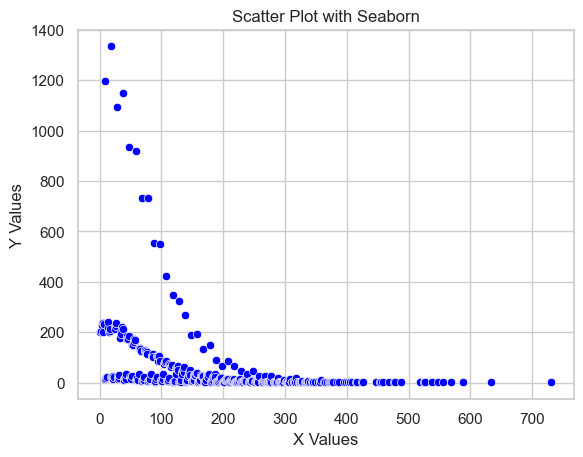

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data

grouped = df_sitios.groupby('num_of_reviews').size().reset_index(name='Count')

# Display the result
print(grouped)


# Create a scatter plot using Seaborn
sns.set(style="whitegrid")
sns.scatterplot(x=grouped.num_of_reviews , y=grouped.Count, color='blue', marker='o')

# Add titles and labels
plt.title("Scatter Plot with Seaborn")
plt.xlabel("X Values")
plt.ylabel("Y Values")

# Show the plot
plt.show()

In [7]:
class ADSAC_DataBase:
    # Constructor method to initialize attributes
    def __init__(self):
        pass
    

    def get_connection():
        # Database connection details
        host = "localhost"         # e.g., "localhost" or the server IP
        database = "ADSAC" # Name of your database
        user = "postgres"     # Username for PostgreSQL
        password = "98020927" # Password for PostgreSQL

        try:
            # Connect to PostgreSQL database
            connection = psycopg2.connect(
                host=host,
                database=database,
                user=user,
                password=password
            )

            # Create a cursor to interact with the database
            cursor = connection.cursor()

            # Example query
            cursor.execute("SELECT version();")

            # Fetch and print the result of the query
            db_version = cursor.fetchone()
            print("Connected to PostgreSQL database:")
            print(db_version)

        except (Exception, psycopg2.Error) as error:
            print("Error connecting to PostgreSQL:", error)
            cursor = None
        self.cursor = cursor
        self.connection = connection

    def close_connection():
        self.cursor.close()
        self.connection.close()
        print("PostgreSQL connection closed.")

    def insert_values(table_name, data):    
        try:
            # Dynamically create the SQL query
            insert_query = f"INSERT INTO {table_name} VALUES (%s, %s, %s)"
            
            # Execute the query
            self.cursor.execute(insert_query, data)

            # Commit the transaction
            self.connection.commit()

            print("Data inserted successfully!")
            

        except (Exception, psycopg2.Error) as error:
            print("Error while inserting data:", error)
            return False
        return True

    def update_values(table_name, column_to_update, new_value, condition_column, condition_value):    

        try:
            # SQL UPDATE query
            update_query = f"""
            UPDATE {table_name}
            SET {column_to_update} = %s
            WHERE {condition_column} = %s
            """

            # Execute the query with parameters
            self.cursor.execute(update_query, (new_value, condition_value))

            # Commit the transaction
            self.connection.commit()

            print(f"Value updated successfully in {table_name}!")

        except (Exception, psycopg2.Error) as error:
            print("Error while updating values:", error)
            return False
        return True

        
    def delete_values(cursor, table_name, condition_column, condition_value):    
        try:
            # SQL DELETE query
            delete_query = f"""
            DELETE FROM {table_name}
            WHERE {condition_column} = %s
            """

            # Execute the query with parameters
            self.cursor.execute(delete_query, (condition_value,))

            # Commit the transaction
            self.connection.commit()

            print(f"Record deleted successfully from {table_name}!")

        except (Exception, psycopg2.Error) as error:
            print("Error while deleting values:", error)
            return False
        return True        